# 🌟 Lab 05: Learned Sparse Representations 與 Seismic

## 學習目標
在本實驗中，您將學習：
1. **Dense vs Sparse Embeddings** - 理解兩種表示法的差異與優劣
2. **SPLADE 模型** - 學習 Learned Sparse Representations 原理
3. **Seismic 索引** - 使用高效的稀疏向量檢索引擎
4. **Hybrid 檢索** - 結合 Dense 和 Sparse 的混合策略

## 為什麼學習 Sparse Representations？
- **可解釋性**: 可以看到哪些詞彙對檢索結果有貢獻
- **效率**: 稀疏向量可以使用倒排索引，檢索更快
- **互補性**: 與 dense embeddings 結合可獲得更好效果

## 技術棧
- **Sparse Model**: SPLADE via `transformers`
- **Sparse Index**: `pyseismic-lsr` (Seismic)
- **Dense Model**: `sentence-transformers`

---

## 📦 Part 1: 環境設置

In [1]:
# 安裝必要套件
!pip install --quiet sentence-transformers
!pip install --quiet transformers torch
!pip install --quiet pyseismic-lsr
!pip install --quiet pandas numpy matplotlib
!pip install --quiet scikit-learn

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple

import torch
from transformers import AutoModelForMaskedLM, AutoTokenizer
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

# 檢查裝置
device = 'cuda'
print(f"✅ 使用裝置: {device}")

/home/user/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ 使用裝置: cuda


---
## 🔍 Part 2: Dense vs Sparse Embeddings

### 比較表

| 特性 | Dense Embedding | Sparse Embedding |
|------|-----------------|------------------|
| **維度** | 固定 (例如 384, 768) | 詞彙表大小 (例如 30,522) |
| **稀疏度** | 所有值都非零 | 大部分值為零 |
| **可解釋性** | 低（每個維度無明確意義）| 高（每個維度對應一個詞）|
| **索引方式** | ANN (近似最近鄰) | 倒排索引 |
| **記憶體** | 相對較高 | 可以很低（只存非零值）|
| **語義捕捉** | 強 | 較弱（但有詞擴展）|

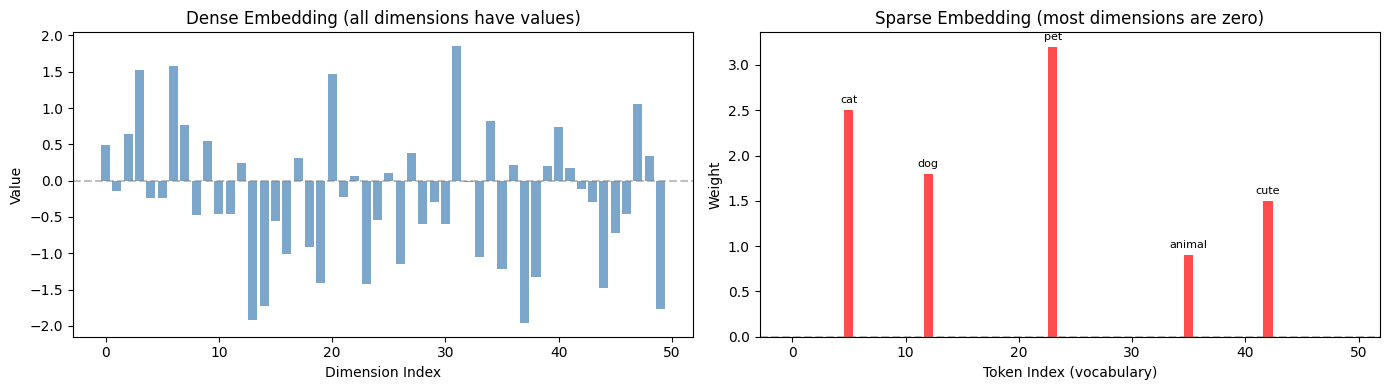


💡 觀察:
   Dense: 所有 50 個維度都有值
   Sparse: 只有 5 個非零值 (10% 稀疏度)


In [3]:
# 視覺化 Dense vs Sparse

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Dense Embedding 視覺化
ax1 = axes[0]
np.random.seed(42)
dense_embedding = np.random.randn(50)  # 模擬 50 維 dense embedding
ax1.bar(range(len(dense_embedding)), dense_embedding, color='steelblue', alpha=0.7)
ax1.set_xlabel('Dimension Index')
ax1.set_ylabel('Value')
ax1.set_title('Dense Embedding (all dimensions have values)')
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Sparse Embedding 視覺化
ax2 = axes[1]
sparse_embedding = np.zeros(50)  # 模擬稀疏向量
sparse_indices = [5, 12, 23, 35, 42]  # 只有 5 個非零位置
sparse_values = [2.5, 1.8, 3.2, 0.9, 1.5]
sparse_embedding[sparse_indices] = sparse_values

colors = ['red' if v > 0 else 'steelblue' for v in sparse_embedding]
ax2.bar(range(len(sparse_embedding)), sparse_embedding, color=colors, alpha=0.7)
ax2.set_xlabel('Token Index (vocabulary)')
ax2.set_ylabel('Weight')
ax2.set_title('Sparse Embedding (most dimensions are zero)')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# 標註非零位置的詞
sample_tokens = ['cat', 'dog', 'pet', 'animal', 'cute']
for idx, token, val in zip(sparse_indices, sample_tokens, sparse_values):
    ax2.annotate(token, (idx, val), textcoords="offset points", 
                 xytext=(0, 5), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print("\n💡 觀察:")
print(f"   Dense: 所有 {len(dense_embedding)} 個維度都有值")
print(f"   Sparse: 只有 {len(sparse_indices)} 個非零值 ({len(sparse_indices)/len(sparse_embedding)*100:.0f}% 稀疏度)")

---
## 🧠 Part 3: SPLADE 模型介紹

### 什麼是 SPLADE？

**SPLADE** (SParse Lexical AnD Expansion) 是一種 learned sparse retrieval 模型：

1. 基於 BERT 的 MLM head 產生詞彙權重
2. 使用 log-saturation 壓縮權重
3. 可以做詞彙擴展（expansion）：query 中沒有的詞也可能有權重

### 公式

$$w_j = \log(1 + \text{ReLU}(\text{BERT}_{\text{MLM}}(x)_j))$$

其中 $j$ 是詞彙表中的 token index。

In [4]:
# 載入 SPLADE 模型

class SPLADEEncoder:
    """
    SPLADE 稀疏編碼器
    """
    
    def __init__(self, model_name: str = "naver/splade-cocondenser-ensembledistil"):
        print(f"📥 載入 SPLADE 模型: {model_name}...")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForMaskedLM.from_pretrained(model_name)
        self.model.eval()
        self.model.to(device)
        print(f"✅ 模型載入完成！")
    
    def encode(self, text: str) -> Dict[str, float]:
        """
        將文本編碼為稀疏向量
        
        Args:
            text: 輸入文本
        
        Returns:
            {token: weight} 字典
        """
        # Tokenize
        inputs = self.tokenizer(
            text, 
            return_tensors='pt', 
            padding=True, 
            truncation=True,
            max_length=512
        ).to(device)
        
        # Forward pass
        with torch.no_grad():
            outputs = self.model(**inputs)
            logits = outputs.logits  # (batch, seq_len, vocab_size)
        
        # SPLADE: log(1 + ReLU(x))
        # 對 attention mask 外的位置清零
        attention_mask = inputs['attention_mask'].unsqueeze(-1)  # (batch, seq_len, 1)
        logits = logits * attention_mask
        
        # Max pooling over sequence length + log-saturation
        relu_log = torch.log1p(torch.relu(logits))  # log(1 + ReLU(x))
        weights = torch.max(relu_log, dim=1).values[0]  # (vocab_size,)
        
        # 取得非零權重
        non_zero_indices = weights.nonzero().squeeze().cpu().numpy()
        non_zero_weights = weights[non_zero_indices].cpu().numpy()
        
        # 轉換為 {token: weight} 格式
        sparse_dict = {}
        if non_zero_indices.ndim == 0:  # 只有一個非零值
            non_zero_indices = [non_zero_indices.item()]
            non_zero_weights = [non_zero_weights.item()]
        
        for idx, weight in zip(non_zero_indices, non_zero_weights):
            token = self.tokenizer.decode([idx])
            if token.strip() and not token.startswith('['):
                sparse_dict[token.strip()] = float(weight)
        
        return sparse_dict
    
    def get_top_tokens(self, sparse_dict: Dict[str, float], top_k: int = 10) -> List[Tuple[str, float]]:
        """取得權重最高的 tokens"""
        sorted_items = sorted(sparse_dict.items(), key=lambda x: x[1], reverse=True)
        return sorted_items[:top_k]

# 載入 SPLADE
try:
    splade = SPLADEEncoder()
    splade_available = True
except Exception as e:
    print(f"⚠️ SPLADE 載入失敗: {e}")
    print("將使用模擬的稀疏向量進行演示")
    splade_available = False

📥 載入 SPLADE 模型: naver/splade-cocondenser-ensembledistil...
✅ 模型載入完成！


In [5]:
# SPLADE 編碼演示

if splade_available:
    test_texts = [
        "What is machine learning?",
        "How do I reset my password?",
        "The weather is nice today.",
    ]
    
    print("📊 SPLADE 稀疏編碼結果\n")
    
    for text in test_texts:
        sparse = splade.encode(text)
        top_tokens = splade.get_top_tokens(sparse, top_k=10)
        
        print(f"Text: '{text}'")
        print(f"Non-zero tokens: {len(sparse)}")
        print("Top 10 tokens:")
        for token, weight in top_tokens:
            print(f"  {token}: {weight:.3f}")
        print("-" * 50)
else:
    print("模擬 SPLADE 輸出範例：")
    print()
    print("Text: 'What is machine learning?'")
    print("Top tokens:")
    print("  learning: 3.245")
    print("  machine: 2.891")
    print("  what: 1.532")
    print("  ai: 1.234")
    print("  algorithm: 0.982")

📊 SPLADE 稀疏編碼結果

Text: 'What is machine learning?'
Non-zero tokens: 72
Top 10 tokens:
  machine: 3.026
  learning: 2.635
  machines: 2.040
  learn: 1.945
  training: 1.091
  learned: 1.022
  technology: 0.816
  pearson: 0.550
  computer: 0.541
  theory: 0.540
--------------------------------------------------
Text: 'How do I reset my password?'
Non-zero tokens: 29
Top 10 tokens:
  password: 3.080
  reset: 2.717
  step: 1.626
  method: 1.332
  re: 1.163
  your: 0.839
  fix: 0.797
  remove: 0.761
  tab: 0.693
  cancel: 0.683
--------------------------------------------------
Text: 'The weather is nice today.'
Non-zero tokens: 38
Top 10 tokens:
  nice: 2.829
  weather: 2.690
  today: 2.481
  now: 1.432
  temperature: 1.299
  winter: 1.018
  lovely: 1.010
  rain: 1.001
  summer: 0.942
  yesterday: 0.800
--------------------------------------------------


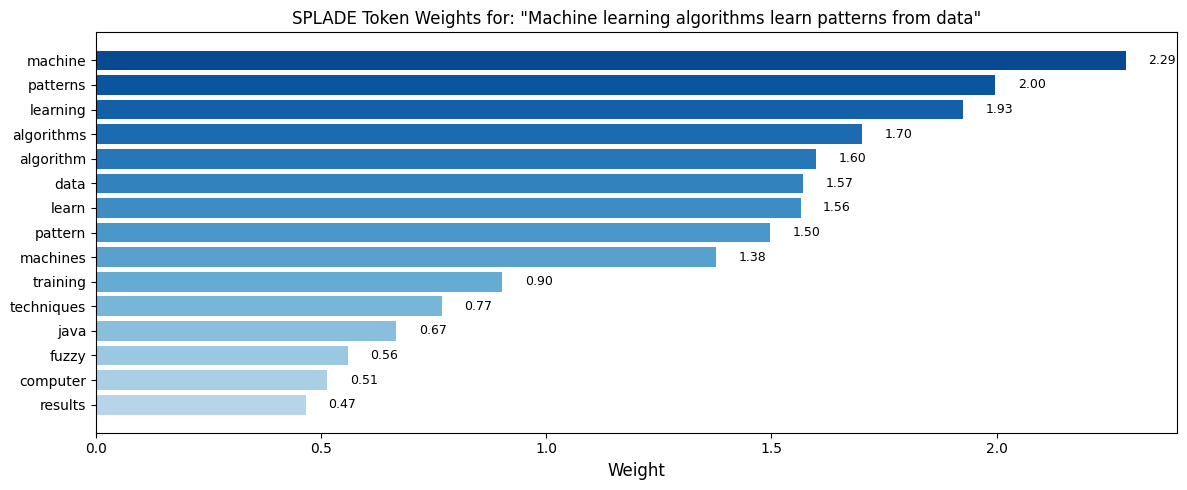


💡 觀察:
- SPLADE 會給原文中的重要詞彙較高權重
- 也會擴展到相關詞彙（如 'algorithm' -> 'algorithms'）


In [6]:
# 視覺化 SPLADE 權重分布

if splade_available:
    text = "Machine learning algorithms learn patterns from data"
    sparse = splade.encode(text)
    top_tokens = splade.get_top_tokens(sparse, top_k=15)
    
    tokens = [t for t, _ in top_tokens]
    weights = [w for _, w in top_tokens]
    
    plt.figure(figsize=(12, 5))
    colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(tokens)))[::-1]
    bars = plt.barh(range(len(tokens)), weights, color=colors)
    plt.yticks(range(len(tokens)), tokens)
    plt.xlabel('Weight', fontsize=12)
    plt.title(f'SPLADE Token Weights for: "{text}"', fontsize=12)
    plt.gca().invert_yaxis()
    
    # 加上數值標籤
    for bar, w in zip(bars, weights):
        plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{w:.2f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print("\n💡 觀察:")
    print("- SPLADE 會給原文中的重要詞彙較高權重")
    print("- 也會擴展到相關詞彙（如 'algorithm' -> 'algorithms'）")

---
## ⚡ Part 4: Seismic 稀疏索引

### 什麼是 Seismic？

**Seismic** 是一個高效的稀疏向量檢索引擎：

- 使用 Rust 實現，效能極高
- 專為 learned sparse representations 設計
- 支援近似檢索，可調整精確度/速度權衡

來源: [GitHub - TusKANNy/seismic](https://github.com/TusKANNy/seismic)

In [7]:
# 準備 Seismic 格式的資料

# 建立文件庫
documents = [
    "Machine learning is a subset of artificial intelligence that enables systems to learn from data.",
    "Deep learning uses neural networks with many layers to process complex patterns.",
    "Natural language processing helps computers understand and generate human language.",
    "Computer vision allows machines to interpret and understand visual information.",
    "Reinforcement learning trains agents to make decisions through trial and error.",
    "The password reset feature allows users to recover their account access.",
    "Customer support is available 24/7 via email, phone, or live chat.",
    "Our return policy allows returns within 30 days of purchase.",
    "International shipping is available to over 100 countries worldwide.",
    "Two-factor authentication adds an extra layer of security to your account.",
]

def create_mock_sparse_vectors(texts: List[str]) -> List[Dict]:
    """
    建立模擬的稀疏向量（當 SPLADE 不可用時）
    """
    sparse_vectors = []
    for i, text in enumerate(texts):
        words = text.lower().split()
        vector = {}
        for word in set(words):
            word = word.strip('.,!?')
            if len(word) > 2:
                vector[word] = np.random.uniform(0.5, 3.0)
        sparse_vectors.append({
            'id': i,
            'content': text,
            'vector': vector
        })
    return sparse_vectors

def create_sparse_vectors_with_splade(texts: List[str], encoder) -> List[Dict]:
    """
    使用 SPLADE 建立稀疏向量
    """
    sparse_vectors = []
    for i, text in enumerate(texts):
        vector = encoder.encode(text)
        sparse_vectors.append({
            'id': i,
            'content': text,
            'vector': vector
        })
    return sparse_vectors

# 建立稀疏向量
print("🔄 建立稀疏向量...")
if splade_available:
    doc_sparse = create_sparse_vectors_with_splade(documents, splade)
else:
    doc_sparse = create_mock_sparse_vectors(documents)

print(f"✅ 建立了 {len(doc_sparse)} 個文件的稀疏向量")
print(f"\n範例:")
print(f"  文件: {doc_sparse[0]['content'][:50]}...")
print(f"  非零 tokens: {len(doc_sparse[0]['vector'])}")
top_5 = sorted(doc_sparse[0]['vector'].items(), key=lambda x: x[1], reverse=True)[:5]
print(f"  Top 5: {top_5}")

🔄 建立稀疏向量...
✅ 建立了 10 個文件的稀疏向量

範例:
  文件: Machine learning is a subset of artificial intelli...
  非零 tokens: 109
  Top 5: [('machine', 2.3883817195892334), ('learning', 2.142791986465454), ('subset', 1.5971441268920898), ('artificial', 1.5273144245147705), ('learn', 1.459946870803833)]


In [8]:
# 儲存為 Seismic 格式 (JSONL)

def save_to_jsonl(sparse_vectors: List[Dict], filepath: str):
    """
    儲存為 Seismic 的 JSONL 格式
    
    格式: {"id": int, "content": str, "vector": {token: weight}}
    """
    with open(filepath, 'w', encoding='utf-8') as f:
        for doc in sparse_vectors:
            line = json.dumps(doc, ensure_ascii=False)
            f.write(line + '\n')
    print(f"✅ 已儲存至: {filepath}")

# 儲存
os.makedirs('data', exist_ok=True)
save_to_jsonl(doc_sparse, 'data/documents.jsonl')

✅ 已儲存至: data/documents.jsonl


In [9]:
# 使用 Seismic 建立索引

try:
    from seismic import SeismicIndex
    
    print("🔄 建立 Seismic 索引...")
    index = SeismicIndex.build('data/documents.jsonl')
    
    print(f"\n✅ Seismic 索引建立完成！")
    print(f"   文件數量: {index.len}")
    print(f"   向量維度: {index.dim}")
    print(f"   平均非零元素: {index.nnz / index.len:.1f}")
    
    # 顯示空間使用
    print("\n📊 空間使用:")
    index.print_space_usage_byte()
    
    seismic_available = True
    
except ImportError:
    print("⚠️ pyseismic-lsr 未安裝")
    print("請執行: pip install pyseismic-lsr")
    seismic_available = False
except Exception as e:
    print(f"⚠️ Seismic 索引建立失敗: {e}")
    seismic_available = False

🔄 建立 Seismic 索引...

✅ Seismic 索引建立完成！
   文件數量: 10
   向量維度: 575
   平均非零元素: 81.4

📊 空間使用:

Building the index...
Configuration { pruning: GlobalThreshold { n_postings: 3500, max_fraction: 1.5 }, blocking: RandomKmeans { centroid_fraction: 0.1, min_cluster_size: 2, clustering_algorithm: RandomKmeansInvertedIndexApprox { doc_cut: 15 } }, summarization: EnergyPreserving { summary_energy: 0.4 }, knn: KnnConfiguration { nknn: 0, knn_path: None }, batched_indexing: None }
Reading the collection...
Number of rows: 10
Elapsed time to read the collection: 0 secs
Distributing and pruning postings: 0 secs
Number of posting lists: 575
Avg posting list length: 1.41
Building summaries: 0 secs
Space Usage:
	Forward Index: 3400 Bytes
	Posting Lists: 273424 Bytes
	  ├─ packed_postings: 15704 Bytes (5.74%)
	  ├─ block_offsets: 18384 Bytes (6.72%)
	  └─ summaries: 239336 Bytes (87.53%)
	Knn: 0 Bytes
	Total: 276824 Bytes


In [15]:
# Seismic 檢索

def search_with_seismic(
    query: str,
    index,
    encoder=None,
    k: int = 5
) -> List[Tuple[int, float]]:
    """
    使用 Seismic 進行檢索
    """
    # 編碼 query
    if encoder:
        query_sparse = encoder.encode(query)
    else:
        # 模擬
        words = query.lower().split()
        query_sparse = {w.strip('.,!?'): np.random.uniform(1, 3) for w in words if len(w) > 2}
    
    # 準備 Seismic 格式
    query_components = np.array(list(query_sparse.keys()), dtype='U30')
    query_values = np.array(list(query_sparse.values()), dtype=np.float32)
    
    # 檢索
    results = index.search(
        query_id="q0",
        query_components=query_components,
        query_values=query_values,
        k=k,
        query_cut=len(query_components),
        heap_factor=0.8
    )
    
    return results

if seismic_available:
    # 測試查詢
    test_queries = [
        "What is machine learning?",
        "How to reset password?",
        "Computer vision applications",
    ]
    
    print("🔍 Seismic 檢索結果\n")
    
    for query in test_queries:
        print(f"Query: '{query}'")
        results = search_with_seismic(
            query, 
            index, 
            encoder=splade if splade_available else None,
            k=3
        )
        
        print("Results:")
        for result in results:
            # 根據我們剛剛看到的 Debug 結構: (query_id, score, doc_id)
            score = result[1]
            doc_id = result[2]
            
            # 把 doc_id 轉成整數，去 documents 裡抓文章出來
            print(f"  [{float(score):.3f}] {documents[int(doc_id)][:60]}...")
            
        print("-" * 60)
else:
    print("⚠️ Seismic 不可用，跳過檢索演示")

🔍 Seismic 檢索結果

Query: 'What is machine learning?'
Results:
  [24.889] Machine learning is a subset of artificial intelligence that...
  [11.694] Deep learning uses neural networks with many layers to proce...
  [10.325] Reinforcement learning trains agents to make decisions throu...
------------------------------------------------------------
Query: 'How to reset password?'
Results:
  [17.301] The password reset feature allows users to recover their acc...
  [2.710] Two-factor authentication adds an extra layer of security to...
  [0.914] Reinforcement learning trains agents to make decisions throu...
------------------------------------------------------------
Query: 'Computer vision applications'
Results:
  [21.318] Computer vision allows machines to interpret and understand ...
  [7.177] Natural language processing helps computers understand and g...
  [2.229] Machine learning is a subset of artificial intelligence that...
-----------------------------------------------------------

---
## 🔀 Part 5: Hybrid 檢索

### 為什麼需要 Hybrid？

- **Dense**: 擅長語義相似度，但可能遺漏關鍵字匹配
- **Sparse**: 擅長關鍵字匹配，但語義理解較弱
- **Hybrid**: 結合兩者優勢！

### 常見融合方法

1. **Linear Combination**: `score = α * dense_score + (1-α) * sparse_score`
2. **Reciprocal Rank Fusion (RRF)**: `score = Σ 1/(k + rank_i)`

In [16]:
# Hybrid 檢索實作

class HybridRetriever:
    """
    結合 Dense 和 Sparse 的混合檢索器
    """
    
    def __init__(
        self,
        dense_model: SentenceTransformer,
        sparse_encoder=None,
        corpus: List[str] = None
    ):
        self.dense_model = dense_model
        self.sparse_encoder = sparse_encoder
        self.corpus = corpus
        
        # 預計算 dense embeddings
        if corpus:
            print("🔄 計算 Dense Embeddings...")
            self.dense_corpus_embeddings = dense_model.encode(corpus)
            print("✅ Dense Embeddings 準備完成")
    
    def dense_search(self, query: str, top_k: int = 10) -> List[Tuple[int, float]]:
        """Dense 檢索"""
        query_emb = self.dense_model.encode(query)
        similarities = cosine_similarity([query_emb], self.dense_corpus_embeddings)[0]
        top_indices = np.argsort(similarities)[::-1][:top_k]
        return [(idx, similarities[idx]) for idx in top_indices]
    
    def sparse_search(self, query: str, top_k: int = 10) -> List[Tuple[int, float]]:
        """Sparse 檢索 (使用簡單的詞彙重疊)"""
        query_tokens = set(query.lower().split())
        scores = []
        
        for i, doc in enumerate(self.corpus):
            doc_tokens = set(doc.lower().split())
            overlap = len(query_tokens & doc_tokens)
            scores.append((i, overlap))
        
        scores.sort(key=lambda x: x[1], reverse=True)
        return scores[:top_k]
    
    def hybrid_search_linear(
        self, 
        query: str, 
        top_k: int = 10, 
        alpha: float = 0.5
    ) -> List[Tuple[int, float]]:
        """
        Linear Combination Hybrid Search
        
        Args:
            query: 查詢
            top_k: 返回結果數
            alpha: Dense 權重 (0-1)
        """
        dense_results = dict(self.dense_search(query, top_k * 2))
        sparse_results = dict(self.sparse_search(query, top_k * 2))
        
        # 正規化分數
        if dense_results:
            max_dense = max(dense_results.values())
            min_dense = min(dense_results.values())
            dense_range = max_dense - min_dense if max_dense != min_dense else 1
            dense_results = {k: (v - min_dense) / dense_range for k, v in dense_results.items()}
        
        if sparse_results:
            max_sparse = max(sparse_results.values())
            if max_sparse > 0:
                sparse_results = {k: v / max_sparse for k, v in sparse_results.items()}
        
        # 合併分數
        all_docs = set(dense_results.keys()) | set(sparse_results.keys())
        hybrid_scores = []
        
        for doc_id in all_docs:
            d_score = dense_results.get(doc_id, 0)
            s_score = sparse_results.get(doc_id, 0)
            combined = alpha * d_score + (1 - alpha) * s_score
            hybrid_scores.append((doc_id, combined))
        
        hybrid_scores.sort(key=lambda x: x[1], reverse=True)
        return hybrid_scores[:top_k]
    
    def hybrid_search_rrf(
        self, 
        query: str, 
        top_k: int = 10, 
        k: int = 60
    ) -> List[Tuple[int, float]]:
        """
        Reciprocal Rank Fusion (RRF)
        
        RRF score = sum(1 / (k + rank_i))
        """
        dense_results = self.dense_search(query, top_k * 2)
        sparse_results = self.sparse_search(query, top_k * 2)
        
        # 計算 RRF 分數
        rrf_scores = {}
        
        for rank, (doc_id, _) in enumerate(dense_results, 1):
            rrf_scores[doc_id] = rrf_scores.get(doc_id, 0) + 1 / (k + rank)
        
        for rank, (doc_id, _) in enumerate(sparse_results, 1):
            rrf_scores[doc_id] = rrf_scores.get(doc_id, 0) + 1 / (k + rank)
        
        results = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)
        return results[:top_k]

# 建立 Hybrid Retriever
print("🔄 建立 Hybrid Retriever...")
import os
os.environ["HF_HOME"] = "./hf_cache"
os.makedirs(os.environ["HF_HOME"], exist_ok=True)
dense_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2",
    cache_folder="./hf_cache",
)
hybrid = HybridRetriever(dense_model, corpus=documents)
print("✅ Hybrid Retriever 準備完成")

🔄 建立 Hybrid Retriever...
🔄 計算 Dense Embeddings...
✅ Dense Embeddings 準備完成
✅ Hybrid Retriever 準備完成


In [17]:
# 比較不同檢索方法

test_query = "How to recover my account password?"

print(f"Query: '{test_query}'\n")
print("=" * 70)

# Dense 檢索
print("\n📗 Dense Search Results:")
dense_results = hybrid.dense_search(test_query, top_k=3)
for idx, score in dense_results:
    print(f"  [{score:.3f}] {documents[idx][:60]}...")

# Sparse 檢索
print("\n📘 Sparse Search Results (keyword matching):")
sparse_results = hybrid.sparse_search(test_query, top_k=3)
for idx, score in sparse_results:
    print(f"  [{score:.1f}] {documents[idx][:60]}...")

# Hybrid 檢索 (Linear)
print("\n📙 Hybrid Search Results (Linear, α=0.5):")
hybrid_linear = hybrid.hybrid_search_linear(test_query, top_k=3, alpha=0.5)
for idx, score in hybrid_linear:
    print(f"  [{score:.3f}] {documents[idx][:60]}...")

# Hybrid 檢索 (RRF)
print("\n📕 Hybrid Search Results (RRF):")
hybrid_rrf = hybrid.hybrid_search_rrf(test_query, top_k=3)
for idx, score in hybrid_rrf:
    print(f"  [{score:.4f}] {documents[idx][:60]}...")

Query: 'How to recover my account password?'


📗 Dense Search Results:
  [0.590] The password reset feature allows users to recover their acc...
  [0.268] Two-factor authentication adds an extra layer of security to...
  [0.187] Customer support is available 24/7 via email, phone, or live...

📘 Sparse Search Results (keyword matching):
  [3.0] The password reset feature allows users to recover their acc...
  [1.0] Machine learning is a subset of artificial intelligence that...
  [1.0] Deep learning uses neural networks with many layers to proce...

📙 Hybrid Search Results (Linear, α=0.5):
  [1.000] The password reset feature allows users to recover their acc...
  [0.217] Two-factor authentication adds an extra layer of security to...
  [0.216] Computer vision allows machines to interpret and understand ...

📕 Hybrid Search Results (RRF):
  [0.0328] The password reset feature allows users to recover their acc...
  [0.0310] Computer vision allows machines to interpret and understand ...


In [ ]:
# Alpha 參數對 Hybrid 效果的影響

query = "machine learning AI algorithms"

alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
results_by_alpha = {}

print(f"Query: '{query}'\n")
print("Alpha 值的影響 (0 = 純 Sparse, 1 = 純 Dense)")
print("=" * 70)

for alpha in alphas:
    results = hybrid.hybrid_search_linear(query, top_k=3, alpha=alpha)
    results_by_alpha[alpha] = results
    
    print(f"\nα = {alpha}:")
    for idx, score in results:
        print(f"  [{score:.3f}] Doc {idx}: {documents[idx][:50]}...")

print("\n💡 觀察:")
print("- α=0: 純粹基於關鍵字匹配")
print("- α=1: 純粹基於語義相似度")
print("- α=0.5: 平衡考慮兩者")

Query: 'machine learning AI algorithms'

Alpha 值的影響 (0 = 純 Sparse, 1 = 純 Dense)

α = 0.0:
  [1.000] Doc 0: Machine learning is a subset of artificial intelli...
  [0.500] Doc 1: Deep learning uses neural networks with many layer...
  [0.500] Doc 4: Reinforcement learning trains agents to make decis...

α = 0.25:
  [1.000] Doc 0: Machine learning is a subset of artificial intelli...
  [0.526] Doc 4: Reinforcement learning trains agents to make decis...
  [0.505] Doc 1: Deep learning uses neural networks with many layer...

α = 0.5:
  [1.000] Doc 0: Machine learning is a subset of artificial intelli...
  [0.553] Doc 4: Reinforcement learning trains agents to make decis...
  [0.510] Doc 1: Deep learning uses neural networks with many layer...

α = 0.75:
  [1.000] Doc 0: Machine learning is a subset of artificial intelli...
  [0.579] Doc 4: Reinforcement learning trains agents to make decis...
  [0.515] Doc 1: Deep learning uses neural networks with many layer...

α = 1.0:
  [1.000] Doc 0:

: 

---
## 🏋️ 練習: 建立你自己的 Hybrid 系統

嘗試為你的應用場景建立一個 Hybrid 檢索系統。

In [ ]:
# TODO: 建立你自己的 Hybrid 系統

# 1. 準備你的文件庫
my_documents = [
    "Your document 1...",
    "Your document 2...",
    # 加入更多...
]

# 2. 建立 Hybrid Retriever
# my_hybrid = HybridRetriever(dense_model, corpus=my_documents)

# 3. 測試查詢
# results = my_hybrid.hybrid_search_linear("your query", alpha=0.6)

print("📝 請修改上面的程式碼，建立你自己的 Hybrid 系統！")

---
## 📝 總結

### 本實驗學到的重點

1. **Dense vs Sparse**
   - Dense: 固定維度，捕捉語義
   - Sparse: 詞彙維度，可解釋性高

2. **SPLADE**
   - Learned sparse representations
   - 結合詞彙匹配與詞彙擴展
   - 基於 BERT MLM head

3. **Seismic**
   - 高效稀疏向量索引
   - 支援近似檢索
   - 使用 JSONL 格式

4. **Hybrid 檢索**
   - 結合 Dense 和 Sparse 優勢
   - Linear Combination 和 RRF 融合方法
   - Alpha 參數可調整權重

### 整體課程回顧

```
Lab 01: Embedding 基礎 → 理解向量表示
Lab 02: 評估指標 → 量化模型效能
Lab 03: 資料準備 → Contrastive Learning & Hard Negatives
Lab 04: Finetune 實作 → 訓練自己的模型
Lab 05: Sparse & Hybrid → 進階檢索技術
```

---
## 📚 參考資源

- [SPLADE Paper](https://arxiv.org/abs/2107.05720)
- [Seismic GitHub](https://github.com/TusKANNy/seismic)
- [Seismic Paper - SIGIR 2024](https://doi.org/10.1145/3626772.3657769)
- [Hybrid Search 最佳實踐](https://www.pinecone.io/learn/hybrid-search-intro/)
- [Reciprocal Rank Fusion](https://plg.uwaterloo.ca/~gvcormac/cormacksigir09-rrf.pdf)